# Data Wrangling

Note: The usage of sklearn libraries will used at the end with a ColumnTransformer()

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("../data/raw/synthetic_coffee_health_10000.csv") # Data comes with an ID column
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


## Train Test Split

We will divide the data to train and evaluate the model with the respective training and testing data.

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Sleep_Quality", axis=1), df["Sleep_Quality"],
                                                    test_size=0.2, random_state=88, stratify=df["Sleep_Quality"])

## Ordinal Encodings

One of the first things to notice is the variables```Healt_Issues```, ```Stress_Level```, and ```Sleep_Quality``` are ordinal variables (they have an order: i.e. *bad*, *neutral*, *good*). This requires a type of encoding that portrays the hierarchy between variables. This is best done with **Scikit-learn's** ```OrdinalEncoder()``` 

In [38]:
print(f"Stress_Level categories: {X_train.Stress_Level.unique()}") #This the ordinal categories for each variable
print(f"Sleep_Quality categories: {y_train.unique()}") 
print(f"Healt_Issues categories: {X_train.Health_Issues.unique()}") #Includes Nans

Stress_Level categories: ['Medium' 'Low' 'High']
Sleep_Quality categories: ['Fair' 'Good' 'Poor' 'Excellent']
Healt_Issues categories: ['Mild' nan 'Moderate' 'Severe']


As seen in the cell above, ```Health_Issues``` has missing values, this would usually be a problem, but not in this case. In the dataset's context, a nan in ```Health_Issues``` means that the user doesn't have any health issues. So we can just replace all nans with "None" or with the highest hierarchy in the category. (All of this will be done later on)

## One-Hot encodings

Continuing with preprocessing, we still have some categories that aren't in numeric form.

In [39]:
transformed_columns = ["Stress_Level", "Sleep_Quality", "Health_Issues"]

object_columns = X_train.select_dtypes(include=["object"]).columns.to_list()
print(f"The variables that still aren't in number form are: {[column for column in object_columns if column not in transformed_columns]}")

The variables that still aren't in number form are: ['Gender', 'Country', 'Occupation']


In [40]:
print(f"Gender categories: {X_train.Gender.unique()}")
print(f"Country categories: {X_train.Country.unique()}")
print(f"Occupation categories: {X_train.Occupation.unique()}")

Gender categories: ['Male' 'Female' 'Other']
Country categories: ['Japan' 'South Korea' 'Mexico' 'Spain' 'USA' 'Brazil' 'Germany' 'France'
 'Norway' 'Italy' 'Netherlands' 'Switzerland' 'Belgium' 'Sweden' 'Canada'
 'UK' 'India' 'Australia' 'Finland' 'China']
Occupation categories: ['Service' 'Student' 'Healthcare' 'Office' 'Other']


Since ```Country``` has a lot of categories, we will try grouping countries by the continent to which they belong

In [41]:
countries_to_continents = {
    "Europe": ["Germany", "Spain", "France", "UK", "Switzerland", "Netherlands",
               "Italy", "Belgium", "Finland", "Sweeden", "Norway"],
    
    "Asia": ["China", "Japan", "South Korea", "India"],
    "America": ["Brazil", "Mexico", "Canada", "USA"],
    "Oceania": ["Australia"]}

After assigning each country to its corresponding continent, we will manually create one-hot vectors using list comprehensions to create new variables in out dataset.

For ```Gender``` and ```Occupation``` a simple one-hot encoding will do

After all this encoding, all of our variables are encoded into numeric values, which allows our ML model to train on the data. But there is still some more preprocessing to do.

### ```DataWrangler``` Class

To encapsulate all the data wrangling seen before, we will create a class that works with Sklearn's ```Pipeline```module.

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder

In [43]:
class DataWrangler(BaseEstimator, TransformerMixin):
    """
    Transformador personalizado para:
    1. Llenar NaNs en 'Health_Issues' con 'None'.
    2. Mapear 'Country' a columnas de continentes.
    """
    def __init__(self):
        # mapeo de paises a continentes realizado anteriormente
        self.countries_to_continents = {
            "Europe": ["Germany", "Spain", "France", "UK", "Switzerland", "Netherlands",
                       "Italy", "Belgium", "Finland", "Sweeden", "Norway"],
            "Asia": ["China", "Japan", "South Korea", "India"],
            "America": ["Brazil", "Mexico", "Canada", "USA"],
            "Oceania": ["Australia"]
        }
        
        self.continent_cols_ = ["is_europe", "is_asia", "is_america", "is_oceania"]
        
        self.ordinal_categories = [["Severe", "Moderate", "Mild", "None"]]
        self.ordinal_encoder = OrdinalEncoder(categories=self.ordinal_categories)

    def fit(self, X: pd.DataFrame, y=None) -> None:
        # el metodo fit si bien no hace nada, es necesario para el pipeline 
        self.feature_names_in_ = list(X.columns)
        
        X_filled = X[["Health_Issues"]].fillna("None")
        self.ordinal_encoder.fit(X_filled)
        return self
    
    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        # Asegurarse de que estamos trabajando con una copia
        X_ = X.copy()
        
        # Mapeo de Continentes
        if 'Country' in X_.columns:
            X_["is_europe"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["Europe"] else 0)
            X_["is_asia"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["Asia"] else 0)
            X_["is_america"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["America"] else 0)
            X_["is_oceania"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["Oceania"] else 0)
            
            # Eliminamos la columna original 'Country'
            X_ = X_.drop("Country", axis=1)
            
        # The dtype of those columns can be changed to bool to optimize storage and byte-usage
        if "Smoking" in X_.columns:
            X_["Smoking"] = X_["Smoking"].astype(bool)
        
        if "Alcohol_Consumption" in X_.columns:
            X_["Alcohol_Consumption"] = X_["Alcohol_Consumption"].astype(bool)
            
        if "ID" in X_.columns:
            X_ = X_.drop("ID", axis=1)
            
        if "Health_Issues" in X_.columns:
            
            X_filled_transformed = X_[["Health_Issues"]].fillna("None")
            X_["Health_Issues"] = self.ordinal_encoder.transform(X_filled_transformed)
            
        return X_
    
    def get_feature_names_out(self, input_features=None) -> np.array:
        """
        Genera los nombres de las columnas de salida.
        """
        if input_features is None:
            input_features = self.feature_names_in_
            
        # Empezamos con la lista de features de entrada
        output_features = list(input_features)
        
        # Aplicamos la misma lógica de 'transform' a la lista
        if "Country" in output_features:
            # 1. Eliminar la columna original
            output_features.remove("Country")
            # 2. Añadir las nuevas columnas de continentes
            output_features.extend(self.continent_cols_)
            
        if "ID" in output_features:
            output_features.remove("ID")
                        
        return np.array(output_features, dtype=object)

## Scaling Numeric Variables

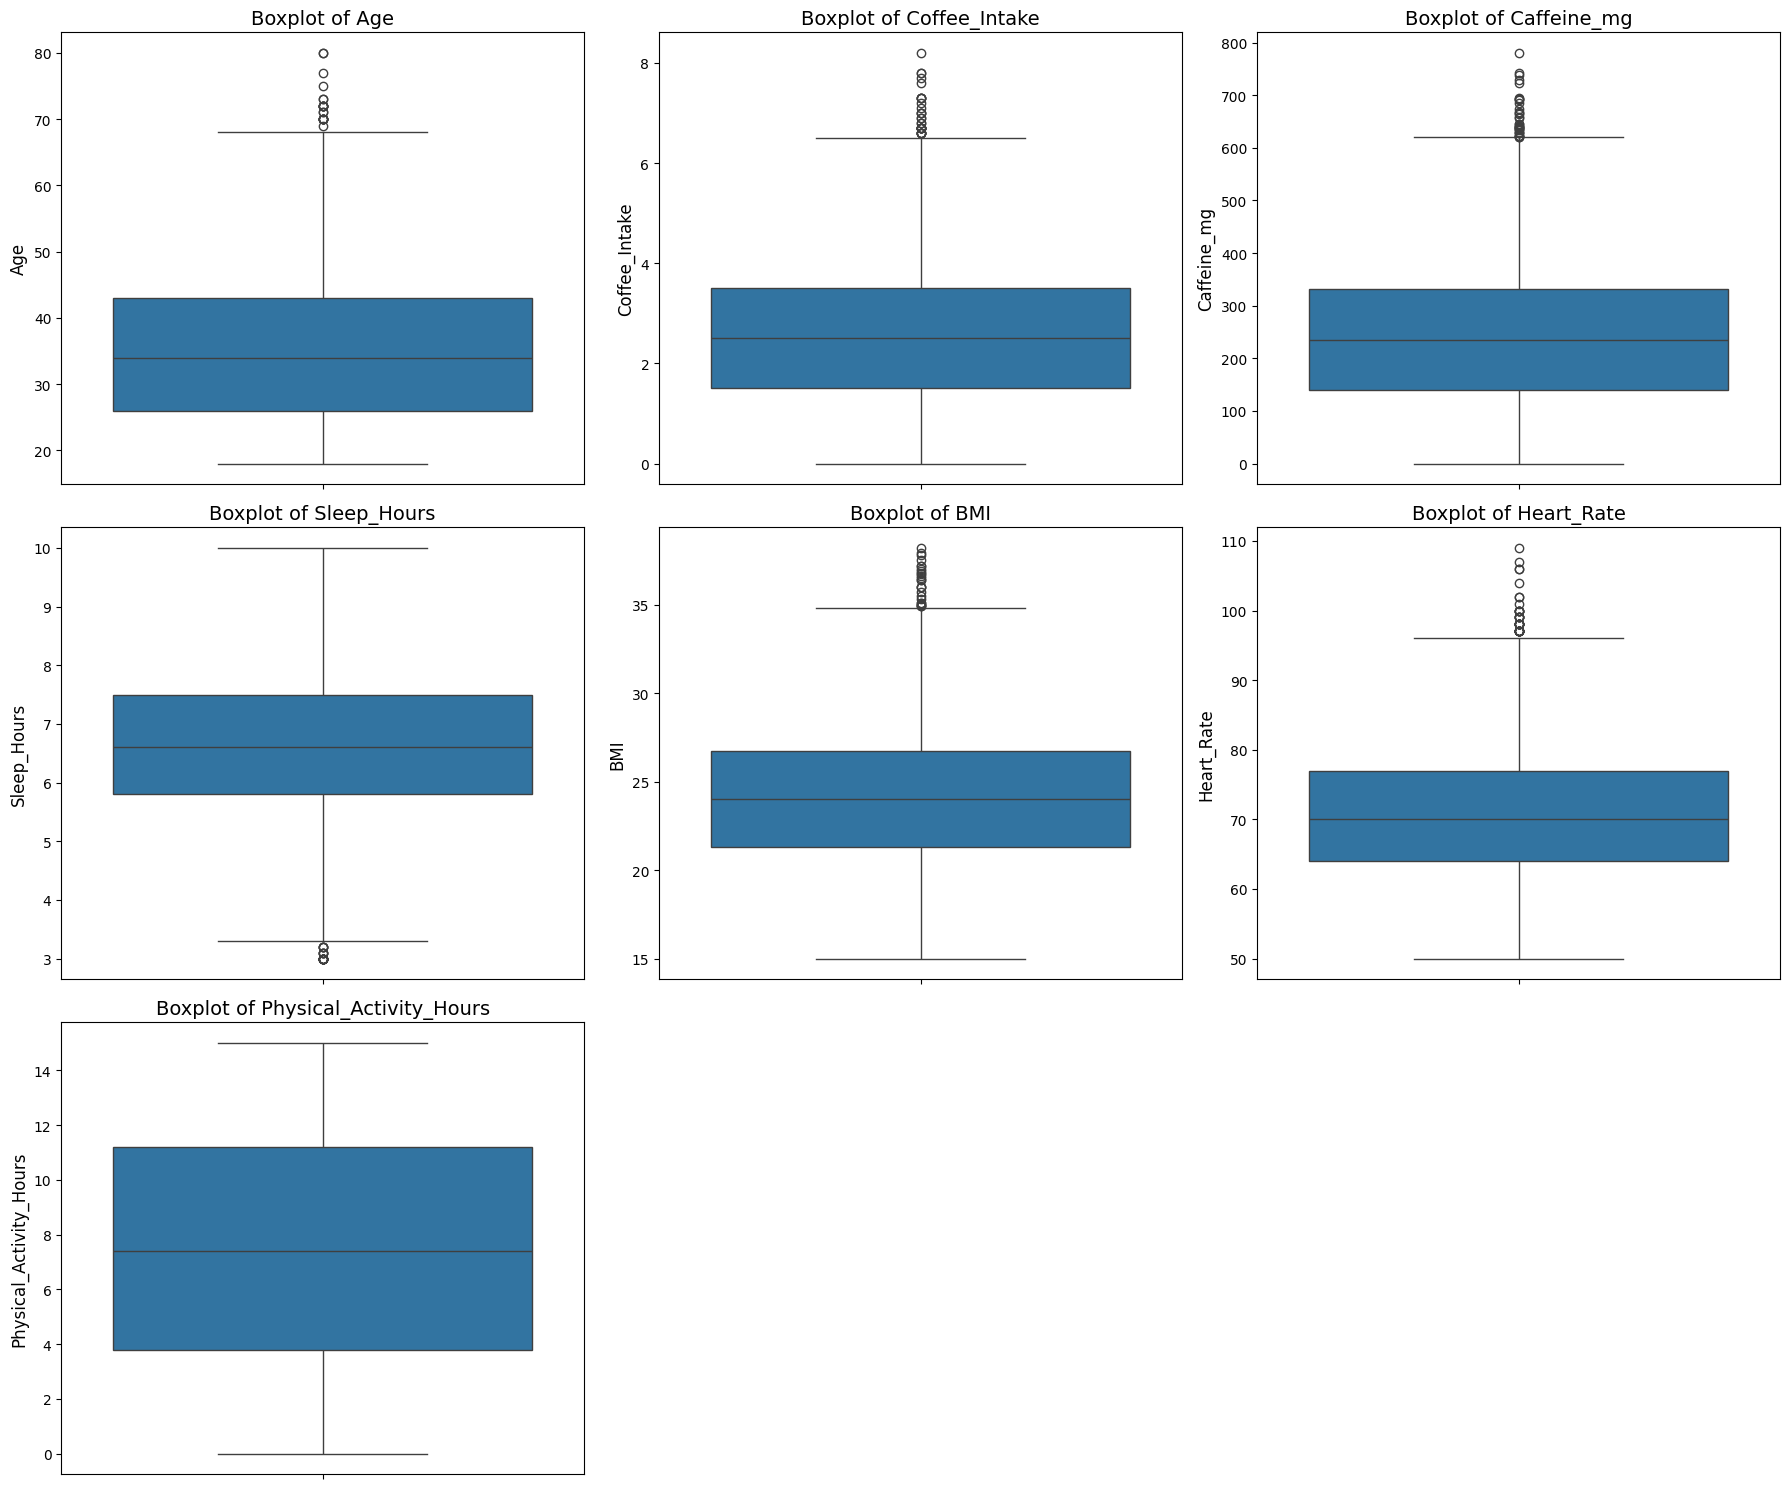

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the continuous and relevant integer columns for boxplots.
# Boxplots are generally not useful for ID, OHE (0/1), or nominal categorical columns.
numeric_cols = [
    'Age', 
    'Coffee_Intake', 
    'Caffeine_mg', 
    'Sleep_Hours', 
    'BMI', 
    'Heart_Rate', 
    'Physical_Activity_Hours'
]

# 2. Set up the figure and axes for the subplots
n_cols = 3 
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # Flatten the array for easy iteration

# 3. Generate a boxplot for each selected numerical column
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=X_train[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)
    axes[i].set_ylabel(col, fontsize=12)

# 4. Hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() # In your local environment, this will display the plots.

since most of our remainding variables has outliers, our best option for scaling is a ```RobustScaler()``` since it uses IQ ranges to scale each value with the following formula:
$$
X_\text{scaled} = \frac{x_i - Q_1(x)}{Q_3 - Q_1}
$$

## Data Processing Pipeline

After analying all of the available columns, our dataset is ready to be transformed to a ML friendly format. ```ColumnTranformer()``` lets us automatize the preprocessing process, and further on implement this process in a fully developed ML Pipeline

In [45]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

numeric_cols = ['Age','Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours'] # Variables that have to be scaled

wrangling_cols = [ "Country", "Smoking", "Alcohol_Consumption", "ID", "Health_Issues"]

ordinal_categories = ["Stress_Level"] # Variables that have a hierarchical order

one_hot_categories = ["Gender", "Occupation"] # Variables that just need one-hot encoding

custom_categories = [["High", "Medium", "Low"]] # Stress Level hierarchical order

ct = ColumnTransformer([
    ("Data_wrangling", DataWrangler(), wrangling_cols), # Data processing seen earlier
    ("robust_scaler", RobustScaler(), numeric_cols), # scaler
    ("ordinal_encoding", OrdinalEncoder(categories=custom_categories), ordinal_categories), #ordinal encoding
    ("onehot_encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_categories), #one hot encoding
],
remainder="passthrough",
verbose_feature_names_out=False)
ct.set_output(transform="pandas")

transformed_data_train = ct.fit_transform(X_train)

# Dropping Variables

As we stated in _01_eda_inicial, the variables we are going to drop are:

- Coffe_Intake
- Gender_Other
- Occupation_Other
- is_oceania
- Health_Issues
- Stress_Level
- ID

## Full Pipeline: Preprocessing + Dropper

In [46]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Un transformador personalizado para eliminar columnas específicas.
    """
    def __init__(self, columns_to_drop: list[str]) -> None:
        self.columns_to_drop = columns_to_drop # Select the previous columns to drop
    
    def fit(self, X, y=None) -> None:
        return self
    
    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        # Asegúrate de que X sea un DataFrame de pandas
        if not isinstance(X, pd.DataFrame):
            raise TypeError("ColumnDropper solo funciona con DataFrames de pandas.")
            
        # Devuelve el DataFrame sin las columnas especificadas
        return X.drop(columns=self.columns_to_drop, errors='ignore')

In [54]:
from sklearn.pipeline import Pipeline

columns_to_drop = [
    "Coffee_Intake",
    "Gender_Other",
    "Occupation_Other",
    "is_oceania",
    "Health_Issues",
    "Stress_Level",
]

full_preprocessing = Pipeline([
    ("preprocessing", ct),
    ("dropper", ColumnDropper(columns_to_drop=columns_to_drop))
])

processed_df_train = full_preprocessing.fit_transform(X_train)

# Data Balancing

In [48]:
from collections import Counter

# Diagnóstico (Antes): Muestra el desbalanceo en el set de entrenamiento
print("--- Before SMOTENC ---")
print(Counter(y_train))

--- Before SMOTENC ---
Counter({'Good': 4509, 'Fair': 1640, 'Excellent': 1082, 'Poor': 769})


A lot of the target's classes are unbalanced, we will use SMOTE to oversample the minority classes. ```SMOTENC``` provides the right tools to correctly create synthetic data taking account of the categoric and continuos variables.

In [52]:
from imblearn.over_sampling import SMOTENC

categorical_features = ["Smoking", "Alcohol_Consumption", "is_europe", "is_asia", "is_america", "Gender_Female", "Gender_Male",
                        "Occupation_Healthcare", "Occupation_Office", "Occupation_Service", "Occupation_Student"]

categorical_indexes = [processed_df_train.columns.get_loc(col)
                       for col in categorical_features
                       if col in processed_df_train.columns]

# Aplicar SMOTENC a los datos de entrenamiento
smote = SMOTENC(categorical_features=categorical_indexes,
                random_state=42)

X_train_res, y_train_res = smote.fit_resample(processed_df_train, y_train)

# # Verificación (Despues): Muestra los nuevos conteos
print("--- After de SMOTENC ---")
print(Counter(y_train_res))

--- After de SMOTENC ---
Counter({'Fair': 4509, 'Good': 4509, 'Poor': 4509, 'Excellent': 4509})


## Exporting Data and Pipeline

In [55]:
import joblib

joblib.dump(full_preprocessing, "../models/preprocessing_pipeline.joblib")

['../models/preprocessing_pipeline.joblib']

In [53]:
full_train_df = pd.concat([X_train_res, y_train_res], axis=1)
full_test_df = pd.concat([X_test, y_test], axis=1)

full_train_df.to_csv("../data/processed/training_data.csv")
full_test_df.to_csv("../data/processed/testing_data.csv")